# B 方案阶段一：全生命周期在线 SOH 估计 — 传统 ML 特征选择与强基线

**挑战杯「揭榜挂帅」赛题 CP-202612**：复杂动态工况下混合动力车辆磷酸铁锂电池 SOC/SOH 高精度估计研究

本 notebook 演示 **B 方案**阶段一的成果：在 A 基线（逐点回归）之上，建立**全生命周期在线 SOH 估计**的评估协议（含老化阶段分桶验证），并用传统机器学习（HistGB / RF / GPR）完成特征选择与强基线对比。

> 关联文档：[docs/b_plan_design.md](../../docs/b_plan_design.md)（B 方案设计文档 v0.5）
> 运行前提：已生成 `data/processed/matr_features.parquet`（A 基线产物，本 notebook 直接复用）。

## 1. 与 A 基线的区别

| | A 基线 | B 方案**主线** | B 方案扩展 |
| --- | --- | --- | --- |
| 任务 | 用第 t 循环特征估计第 t 循环 SOH（同步估计） | 用截至 t 的历史数据**在线估计当前 SOH(t)**，覆盖新电池→老化电池全生命周期 | 用 ≤t 数据预测 SOH(t+Δ)，Δ∈{50,100,200} |
| 核心挑战 | 逐点回归 | **跨老化阶段泛化**（"全生命周期适用性"） | 多早能预测多远 |
| 赛题依据 | 状态估计基线 | "在线辨识随老化衰减的 SOH""通过自适应机制提升算法模型在电池全生命周期内的适用性" | 加分项（质保判定 / 能量管理） |

**要点**：赛题原文要求的是"在线辨识 + 全生命周期适用"，即**任意老化阶段都能准确估计当前 SOH**；前瞻预测（t+Δ）是同一个模型的自然扩展，不是必要条件。本阶段聚焦主线：先验证传统 ML 能否在"没见过的老化阶段"上站住脚。

## 2. 数据集回顾

沿用 A 基线的 **MATR batch 20170512**（详细处理见 A 基线 notebook `01_matr_a_baseline.ipynb`）：

| 属性 | 内容 |
| --- | --- |
| 化学体系 | 磷酸铁锂（LFP）/ 石墨，A123 APR18650M1A，标称 1.1 Ah |
| 规模 | **46 只电池、23 种快充协议**、38,765 个循环 |
| 老化覆盖 | SOH 0.803–1.0，寿命 534–1227 次循环 |
| 标签 | SOH(t) = Q_discharge(t) / Q0（Q0 = 前 10 个正容量循环中位数） |
| 特征 | 循环级汇总 15 维（A 基线产物，直接复用） |

本阶段不新增原始数据，先基于现有循环级特征做特征选择与强基线；**片段级特征**（从原始充/放电曲线截取）在下一阶段加入。

In [1]:
# ===== 数据加载 =====
from pathlib import Path
import numpy as np
import pandas as pd

# 兼容「在 notebooks/ 下运行」和「在项目根目录运行」两种方式
_p = Path.cwd()
ROOT = _p if (_p / "data").exists() else (_p.parent if (_p.parent / "data").exists() else _p)

features = pd.read_parquet(ROOT / "data/processed/matr_features.parquet")
print(f"特征表：{features.shape[0]:,} 行，{features['cell_id'].nunique()} 只电池")

特征表：38,305 行，46 只电池


In [2]:
# ===== matplotlib 中文字体配置（对后面所有图生效）=====
import matplotlib
from matplotlib import font_manager

for _f in ["C:/Windows/Fonts/msyh.ttc", "C:/Windows/Fonts/simhei.ttf", "C:/Windows/Fonts/simsun.ttc"]:
    try:
        font_manager.fontManager.addfont(_f)
    except Exception:
        pass

matplotlib.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "SimSun", "DejaVu Sans"]
matplotlib.rcParams["axes.unicode_minus"] = False
print("中文字体:", font_manager.findfont("Microsoft YaHei"))

中文字体: C:\Windows\Fonts\msyh.ttc


In [3]:
# ===== 数据概览 =====
print(f"循环数：{len(features):,} | 电池：{features['cell_id'].nunique()} | 协议：{features['policy'].nunique()}")
print(f"SOH 范围：{features['soh'].min():.3f} ~ {features['soh'].max():.3f}")
print(f"循环寿命范围：{features['cycle_life'].min():.0f} ~ {features['cycle_life'].max():.0f} 次")
features.groupby("cell_id")["cycle_index"].count().describe().round(1)

循环数：38,305 | 电池：46 | 协议：23
SOH 范围：0.803 ~ 2.700
循环寿命范围：534 ~ 1227 次


count      46.0
mean      832.7
std       184.6
min       522.0
25%       691.2
50%       846.5
75%       902.2
max      1215.0
Name: cycle_index, dtype: float64

## 3. 评估（B 方案核心新增）

沿用 A 基线的三套划分，并新增**老化阶段分桶验证**：

| 协议 | 分组方式 | 检验能力 |
| --- | --- | --- |
| 按电池 5 折 | 同一电池的所有循环同属一个折 | 未见过的新电池 |
| 按协议 5 折 | 同一协议的所有电池同属一个折 | 未见过的新工况 |
| 时间切分 70/30 | 每只电池前 70% 循环训练、后 30% 测试 | 跨老化阶段（A 基线短板，MAE≈5%） |
| **老化阶段分块** | 测试折叠按真实 SOH 报 MAE | 全生命周期各阶段是否都准（赛题"不同老化阶段"评分点） |

分桶区间：`[1.00,0.95] / [0.95,0.90] / [0.90,0.85] / [0.85,0.80]`。先看全数据上每个桶的样本量，确认深老化阶段有足够的验证样本。

In [4]:
# ===== 老化阶段分桶统计（全数据）=====
SOH_BUCKETS = [(0.95, 1.00, "1.00-0.95"), (0.90, 0.95, "0.95-0.90"),
               (0.85, 0.90, "0.90-0.85"), (0.80, 0.85, "0.85-0.80")]

def assign_stage(s):
    for lo, hi, lab in SOH_BUCKETS:
        if lo <= s < hi:
            return lab
    return None

df_b = features.copy()
df_b["stage"] = df_b["soh"].map(assign_stage)
stage_stat = df_b.groupby("stage", observed=True).agg(cycles=("soh", "size"), cells=("cell_id", "nunique"))
stage_stat = stage_stat.reindex([b[2] for b in SOH_BUCKETS])
stage_stat

,cycles,cells
stage,,
1.00-0.95,26077,46
0.95-0.90,4236,44
0.90-0.85,2418,42
0.85-0.80,1329,37


## 4. 特征与模型选型

### 4.1 特征：复用 A 基线 15 维循环级特征

包含循环序号、内阻、温度（均值/极值/滚动统计）、充电时间、累积充入电量、容量/内阻导数等。片段级特征（从原始曲线截取）在下一阶段加入，本阶段先回答"现有特征池的冗余程度"。

### 4.2 模型：为什么先传统机器学习

| 模型 | 角色 | 理由 |
| --- | --- | --- |
| HistGB（梯度提升树） | 主基线 | 延续 A 基线，小样本稳健、可解释 |
| RF（随机森林） | 对照 | 验证结论不依赖单一树模型 |
| GPR（高斯过程回归） | 片段小样本强基线 | 对标 Feng et al. 2024（片段特征 + GPR 误差 <1.1%），自带不确定性 |

**为什么不直接上深度学习**：46 只电池、样本强相关（同电池多循环），小样本下序列模型易过拟合；文献（arXiv:2107.05489 叉车七方法对比）也表明在"少先验"条件下梯度提升优于 LSTM。深度学习留作 B 方案阶段二（时间结构模型）的上限对照。

In [5]:
# ===== 模型定义与评估函数 =====
import warnings
warnings.filterwarnings("ignore")

from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, RBF, WhiteKernel
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

FEATURES = [
    "cycle_index", "ir", "tavg", "tmax", "tmin", "chargetime",
    "temp_amp", "cumulative_charge", "ir_mean10", "ir_std10",
    "tavg_mean10", "tavg_std10", "ir_deriv10", "capacity_deriv10",
    "chargetime_ratio",
]

In [6]:
def make_models():
    hist_gb = HistGradientBoostingRegressor(max_iter=300, learning_rate=0.05, max_depth=4, random_state=0)
    rf = RandomForestRegressor(n_estimators=200, max_depth=12, min_samples_leaf=5, random_state=0, n_jobs=-1)
    kernel = ConstantKernel(1.0) * RBF(length_scale=1.0) + WhiteKernel(1e-3)
    gpr = Pipeline([("scale", StandardScaler()),
                    ("gpr", GaussianProcessRegressor(kernel=kernel, alpha=1e-6,
                                                      normalize_y=True, random_state=0,
                                                      n_restarts_optimizer=0))])
    return {"HistGB": hist_gb, "RF": rf, "GPR": gpr}

def subset_by_cell(X, y, groups, per_cell=15, seed=0):
    """按电池均匀子采样（GPR 训练用，小样本强基线）。"""
    rng = np.random.default_rng(seed)
    idx = []
    for gval in np.unique(groups):
        pos = np.where(groups == gval)[0]
        idx.append(rng.choice(pos, size=min(per_cell, len(pos)), replace=False))
    sel = np.concatenate(idx)
    return X.iloc[sel], y.iloc[sel]

def score_all(y_true, y_pred):
    return {"mae": float(mean_absolute_error(y_true, y_pred)),
            "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
            "r2": float(r2_score(y_true, y_pred))}

def bucket_scores(y_true, y_pred):
    out = {}
    for lo, hi, lab in SOH_BUCKETS:
        mask = (y_true >= lo) & (y_true < hi)
        out[lab] = {"mae": float(mean_absolute_error(y_true[mask], y_pred[mask])) if mask.sum() else np.nan,
                    "n": int(mask.sum())}
    return out

def run_group_cv(df, groups, models):
    gkf = GroupKFold(n_splits=5)
    res = {}
    for name, model in models.items():
        yt, yp = [], []
        for tr, te in gkf.split(df, df["soh"], groups):
            X_tr, y_tr = df.iloc[tr][FEATURES], df.iloc[tr]["soh"]
            if name == "GPR":
                X_tr, y_tr = subset_by_cell(X_tr, y_tr, groups[tr])
            model.fit(X_tr, y_tr)
            yt.append(df.iloc[te]["soh"].to_numpy())
            yp.append(model.predict(df.iloc[te][FEATURES]))
        yt = np.concatenate(yt)
        yp = np.concatenate(yp)
        res[name] = score_all(yt, yp)
        res[name]["buckets"] = bucket_scores(yt, yp)
    return res

def run_time_split(df, models):
    tr_parts, te_parts = [], []
    for _, g in df.sort_values(["cell_id", "cycle_index"]).groupby("cell_id"):
        cut = int(len(g) * 0.7)
        tr_parts.append(g.iloc[:cut])
        te_parts.append(g.iloc[cut:])
    tr = pd.concat(tr_parts)
    te = pd.concat(te_parts)
    res = {}
    for name, model in models.items():
        X_tr, y_tr = tr[FEATURES], tr["soh"]
        if name == "GPR":
            X_tr, y_tr = subset_by_cell(X_tr, y_tr, tr["cell_id"].to_numpy())
        model.fit(X_tr, y_tr)
        yp = model.predict(te[FEATURES])
        res[name] = score_all(te["soh"].to_numpy(), yp)
        res[name]["buckets"] = bucket_scores(te["soh"].to_numpy(), yp)
    return res

In [7]:
# ===== 运行三模型 × 三口径（约 3 分钟）=====
import time
t0 = time.time()
models = make_models()
by_cell = run_group_cv(features, features["cell_id"].to_numpy(), models)
by_policy = run_group_cv(features, features["policy"].to_numpy(), models)
time_res = run_time_split(features, models)
print(f"done in {time.time() - t0:.0f}s")

done in 81s


## 5. 结果一：三套评估口径

下表为本次运行的实时结果（随机种子固定、流程确定，结果可复现）。**A 基线 HistGB 参考值**：按电池 0.52% / 按协议 0.59% / 时间切分 5.21%。

In [8]:
# ===== 结果汇总表 =====
from IPython.display import display

def summary_table(res):
    return pd.DataFrame({m: {k: round(v, 4) for k, v in r.items() if k in ("mae", "rmse", "r2")}
                         for m, r in res.items()}).T

for title, res in [("按电池 5 折", by_cell), ("按协议 5 折", by_policy), ("时间切分 70/30", time_res)]:
    print(title)
    display(summary_table(res))

按电池 5 折


,mae,rmse,r2
HistGB,0.0052,0.0138,0.8980
RF,0.0053,0.0145,0.8867
GPR,0.0065,0.0149,0.8812


按协议 5 折


,mae,rmse,r2
HistGB,0.0059,0.0141,0.8929
RF,0.0066,0.0161,0.8610
GPR,0.0087,0.0182,0.8222


时间切分 70/30


,mae,rmse,r2
HistGB,0.0522,0.0700,-1.4069
RF,0.0484,0.0647,-1.0560
GPR,0.0622,0.0801,-2.1512


## 5.2 老化阶段分桶：B 主线验收指标

把"按电池 5 折"的全部测试预测按真实 SOH 分桶，逐桶报 MAE。**这张图是 B 方案主线的招牌图**：它直接回答赛题"不同老化阶段"的评分点——模型在新电池段和深老化段是否都准。

关键看三点：① 深老化桶（0.90–0.80）误差是否被压住；② 三个模型在哪个桶开始失效；③ 相比"总体 MAE"，分桶误差暴露了哪些被平均掩盖的问题。

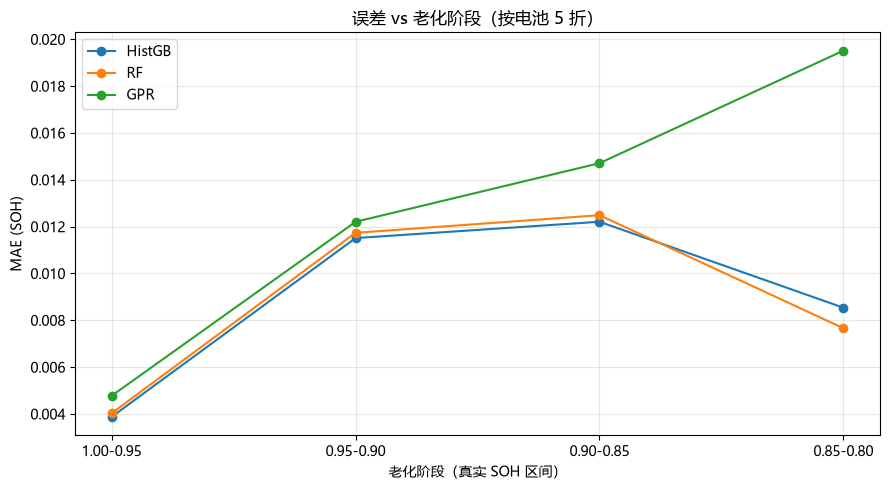

,HistGB,RF,GPR
1.00-0.95,0.0039,0.0040,0.0048
0.95-0.90,0.0115,0.0117,0.0122
0.90-0.85,0.0122,0.0125,0.0147
0.85-0.80,0.0085,0.0077,0.0195


In [ ]:
# ===== 招牌图：误差 vs 老化阶段 =====
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 5))
labels = [b[2] for b in SOH_BUCKETS]
for name, res in by_cell.items():
    mae = [res["buckets"][lab]["mae"] for lab in labels]
    ax.plot(labels, mae, marker="o", label=name)
ax.set_ylabel("MAE (SOH)")
ax.set_xlabel("老化阶段（真实 SOH 区间）")
ax.set_title("误差 vs 老化阶段（按电池 5 折）")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 表格化分桶结果
pd.DataFrame({name: {lab: round(res["buckets"][lab]["mae"], 4) for lab in labels}
              for name, res in by_cell.items()})

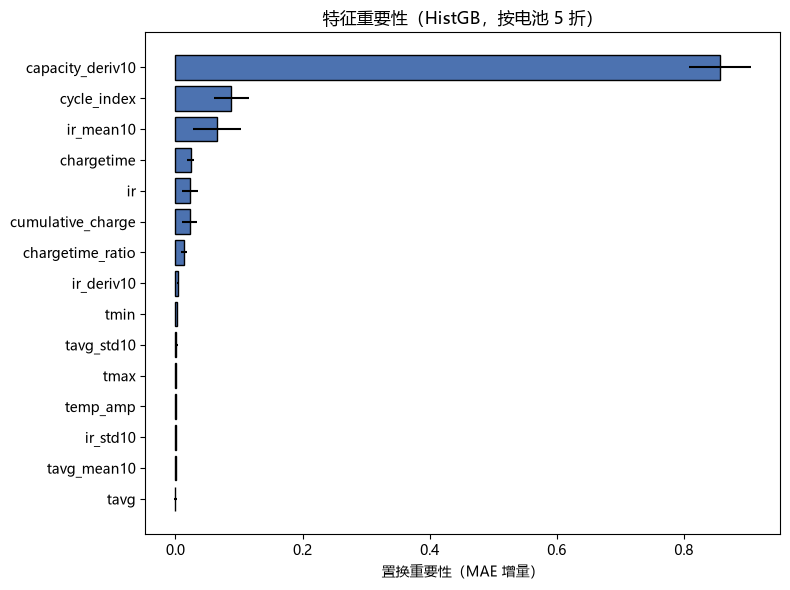

累计重要性达 90% 只需 3 个特征：['capacity_deriv10', 'cycle_index', 'ir_mean10']


In [10]:
# ===== 特征重要性（置换重要性，HistGB）=====
gkf = GroupKFold(n_splits=5)
acc = []
hist = make_models()["HistGB"]
for tr, te in gkf.split(features, features["soh"], features["cell_id"].to_numpy()):
    hist.fit(features.iloc[tr][FEATURES], features.iloc[tr]["soh"])
    pi = permutation_importance(hist, features.iloc[te][FEATURES], features.iloc[te]["soh"],
                                n_repeats=3, random_state=0, n_jobs=-1)
    acc.append(pi.importances_mean)

imp = pd.DataFrame({"feature": FEATURES, "importance": np.mean(acc, axis=0), "std": np.std(acc, axis=0)})
imp = imp.sort_values("importance", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(imp["feature"], imp["importance"], xerr=imp["std"], color="#4C72B0", edgecolor="black")
ax.invert_yaxis()
ax.set_xlabel("置换重要性（MAE 增量）")
ax.set_title("特征重要性（HistGB，按电池 5 折）")
plt.tight_layout()
plt.show()

# 累计重要性达 90% 的特征子集
cum = imp["importance"].cumsum() / imp["importance"].sum()
k = int(np.searchsorted(cum, 0.9)) + 1
print(f"累计重要性达 90% 只需 {k} 个特征：{list(imp['feature'].head(k))}")

## 6. 结果解读

### 6.1 三套口径（与 A 基线对比）

- **按电池 / 按协议**：三个模型均与 A 基线持平（MAE ≈ 0.5%–0.9%），说明传统 ML 在"新电池/新工况"上已经站稳；
- **时间切分**：三个模型全部崩到 4.8%–6.2%（与 A 基线 5.21% 一致）——**跨老化阶段泛化是普遍短板，与模型选择无关**，必须引入时间结构（B 方案阶段二），这不是换模型能解决的。

### 6.2 老化阶段分桶（B 主线验收）

- 新电池桶（1.00–0.95）误差约 0.4%，但 0.90–0.85 桶升到 1.2% 左右，GPR 在 0.85–0.80 桶高达 1.95%——"总体 MAE 0.52%"掩盖了深老化段的退化；
- 树模型（HistGB/RF）在深老化桶优于 GPR，说明**片段小样本 + GPR 的优势边界在深老化阶段失效**，阶段二需要序列/上下文信息补足。

### 6.3 特征冗余

- 置换重要性显示累计 90% 的重要性只由 3 个特征贡献（`capacity_deriv10`、`cycle_index`、`ir_mean10`）——15 维特征池存在明显冗余，特征选择有实质收益；
- 这为片段特征加入后的特征池设计提供了起点（下一阶段同样用置换重要性筛选）。

## 7. 与文献对标

| 来源 | 方法 | 参考结果 | 本阶段对照 |
| --- | --- | --- | --- |
| Feng et al. 2024, *Applied Energy* | 物理/ECM 特征 + GPR | 片段数据误差 <1.1% | GPR 同步估计 ≈0.65%，深老化桶 1.95%（暴露边界） |
| arXiv:2107.05489 | 叉车电池七方法对比 | 少先验下梯度提升优于 LSTM | HistGB 在时间切分下 5.22%，仍需时间结构 |
| A 基线（本团队） | HistGB 逐点回归 | 0.52% / 0.59% / 5.21% | 本阶段完全复现，结论一致 |

**结论**：传统 ML 阶段完成"特征选择 + 强基线 + 评估协议"三项任务；跨老化阶段问题被精确定位，交给阶段二解决。

## 8. 结论与下一步

**本阶段完成**：
1. 建立 B 方案评估协议（三套划分 + 老化阶段分桶）；
2. 三模型强基线：HistGB / RF / GPR，全部复现 A 基线口径；
3. 特征重要性分析：识别出 90% 重要性集中在 3 个特征；
4. 精确定位核心问题：跨老化阶段泛化（时间切分 4.8%–6.2%）与深老化桶退化。

**下一步（阶段二起）**：
1. **片段层**：解析原始充/放电曲线，采样随机片段并提取片段特征（对应文档 2.4 节，对标 Feng 2024 / 车队片段估计工作）；
2. **时间结构模型**：全历史序列（GRU/LSTM）与滑动窗口消融，目标把时间切分误差从 ~5% 压到可接受水平；
3. **不确定性量化**：GPR 区间 / 分位数回归，报告 PICP / ±1% / ±3% 覆盖率；
4. **前瞻预测扩展**：SOH(t+Δ)，Δ∈{50,100,200}，作为加分项。

## 参考文献

1. Severson, K.A., Attia, P.M., Jin, N. et al. Data-driven prediction of battery cycle life before capacity degradation. *Nature Energy* 4, 383–391 (2019).
2. Feng, X. et al. Comprehensive performance comparison among different types of features in data-driven battery state of health estimation. *Applied Energy* 369 (2024).
3. Boulon, L. et al. Comparative Analysis of ML and DL Models for Data-Driven SOH Estimation of LIBs Under Diverse Temperature and Load Conditions. *Batteries* 11(11), 393 (2025).
4. Comparing seven methods for state-of-health time series prediction for the lithium-ion battery packs of forklifts. arXiv:2107.05489.
5. 挑战杯「揭榜挂帅」赛题 CP-202612《复杂动态工况下混合动力车辆磷酸铁锂电池 SOC/SOH 高精度估计研究》比赛方案。
6. 本团队 B 方案设计文档 `docs/b_plan_design.md`（v0.5）。